# 04 — 从 QOS sketch 到分类读出的桥梁

最简单的自然学习任务是 centroid / mean-difference classifier：

$$
w=\mathbb E[yx],\qquad
\widehat y(x')=\operatorname{sign}(x'^Tw).
$$

如果能制备归一化量子态 $|w\rangle$ 和 $|x'\rangle$，Hadamard test
可估计：

$$
r(x')=\operatorname{Re}\langle x'|w\rangle,
\qquad
P(0)=\frac{1+r(x')}{2}.
$$

本 notebook 先验证“流式目标向量 → 重叠读出 → 分类”的后半条链路。
**当前 $|w\rangle$ 使用理想归一化占位，尚未由通用向量 QOS 门级制备。**
因此这是下一阶段的接口测试，不是完整 QOS 分类器。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260728

## Hadamard-test 重叠读出线路

下面是后半段分类读出的逻辑图。数据寄存器从 $|0\cdots0\rangle$ 开始，
受控操作代表 $U_x^\dagger U_w$：

$$
U_w|0\rangle=|w\rangle,\qquad
U_x|0\rangle=|x'\rangle.
$$

测量 ancilla 得到

$$
P(0)=\frac{1+\operatorname{Re}\langle x'|w\rangle}{2}.
$$

图中的受控门是抽象模块；当前 notebook 仍使用理想重叠数值，而不是声称已经
完成 $U_w$ 的门级 QOS 制备。

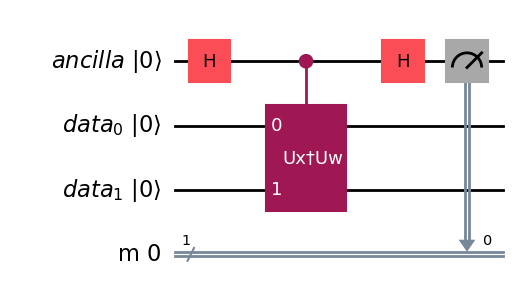

In [2]:
from pathlib import Path

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate

ancilla_register = QuantumRegister(1, "ancilla")
data_register = QuantumRegister(2, "data")
readout_register = ClassicalRegister(1, "m")
hadamard_test_circuit = QuantumCircuit(
    ancilla_register,
    data_register,
    readout_register,
)

hadamard_test_circuit.h(ancilla_register[0])
overlap_gate = UnitaryGate(
    np.eye(4),
    label="Ux†Uw",
)
hadamard_test_circuit.append(
    overlap_gate.control(1),
    [ancilla_register[0], *list(data_register)],
)
hadamard_test_circuit.h(ancilla_register[0])
hadamard_test_circuit.measure(ancilla_register[0], readout_register[0])

asset_dir = Path("../assets/circuits")
asset_dir.mkdir(parents=True, exist_ok=True)
hadamard_figure = hadamard_test_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
hadamard_figure.savefig(
    asset_dir / "hadamard-overlap-test.png",
    dpi=180,
    bbox_inches="tight",
)
hadamard_figure

In [3]:
def make_binary_problem(num_samples, dimension, seed, label_noise=0.35):
    rng = np.random.default_rng(seed)
    teacher = rng.normal(size=dimension)
    teacher /= np.linalg.norm(teacher)
    features = rng.normal(size=(num_samples, dimension))
    latent = features @ teacher + rng.normal(
        scale=label_noise, size=num_samples
    )
    labels = np.where(latent >= 0, 1, -1)
    return features, labels, teacher


def streaming_centroid(feature_rows, labels):
    iterator = iter(zip(feature_rows, labels))
    try:
        first_x, first_y = next(iterator)
    except StopIteration as exc:
        raise ValueError("stream must contain at least one sample.") from exc

    accumulator = first_y * np.asarray(first_x, dtype=float)
    count = 1
    for x_row, label in iterator:
        accumulator += label * np.asarray(x_row, dtype=float)
        count += 1
    return accumulator / count


def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    if np.any(norms == 0):
        raise ValueError("zero feature vector cannot be amplitude normalized.")
    return matrix / norms


def exact_overlap_scores(test_features, weight_vector):
    weight_state = weight_vector / np.linalg.norm(weight_vector)
    test_states = normalize_rows(test_features)
    return np.real(test_states @ weight_state)


def hadamard_test_estimate(overlap_scores, shots, rng):
    probabilities_zero = (1 + np.asarray(overlap_scores)) / 2
    successes = rng.binomial(shots, probabilities_zero)
    return 2 * successes / shots - 1


def accuracy(labels, predictions):
    return float(np.mean(np.asarray(labels) == np.asarray(predictions)))


def balanced_accuracy(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    recalls = []
    for label in (-1, 1):
        mask = labels == label
        recalls.append(np.mean(predictions[mask] == label))
    return float(np.mean(recalls))

## 构造 $D=4$ 的合成流式任务

为便于重复实验，数据先由固定 seed 生成；`streaming_centroid` 本身逐行消费，
不保存历史样本。完整的公平内存实验还需单独测量数据生成器和控制器内存。

In [4]:
D = 4
N_TRAIN = 600
N_TEST = 300

train_x, train_y, teacher = make_binary_problem(
    N_TRAIN, D, seed=SEED
)
test_x, test_y, _ = make_binary_problem(
    N_TEST, D, seed=SEED + 1
)

# 保持同一个 teacher，重新生成测试标签。
test_rng = np.random.default_rng(SEED + 2)
test_y = np.where(
    test_x @ teacher + test_rng.normal(scale=0.35, size=N_TEST) >= 0,
    1,
    -1,
)

weight = streaming_centroid(train_x, train_y)
exact_scores = exact_overlap_scores(test_x, weight)
exact_predictions = np.where(exact_scores >= 0, 1, -1)

print("D:", D)
print("Streaming accumulator size:", weight.nbytes, "bytes")
print("Exact overlap accuracy:", accuracy(test_y, exact_predictions))
print(
    "Exact overlap balanced accuracy:",
    balanced_accuracy(test_y, exact_predictions),
)
print("Median classification margin:", np.median(np.abs(exact_scores)))

D: 4
Streaming accumulator size: 32 bytes
Exact overlap accuracy: 0.8766666666666667
Exact overlap balanced accuracy: 0.876778093883357
Median classification margin: 0.3796960476349275


## finite-shot Hadamard-test 读出

分类是否被测量噪声翻转，取决于 margin
$\gamma(x')=|\langle x'|w\rangle|$。接近决策边界的点最容易出错。

In [5]:
shot_values = [32, 128, 512, 2048, 8192]
REPEATS = 100
master_rng = np.random.default_rng(SEED + 3)
rows = []

for shots in shot_values:
    accuracies = []
    balanced_accuracies = []
    for _ in range(REPEATS):
        estimated_scores = hadamard_test_estimate(
            exact_scores, shots, master_rng
        )
        predictions = np.where(estimated_scores >= 0, 1, -1)
        accuracies.append(accuracy(test_y, predictions))
        balanced_accuracies.append(
            balanced_accuracy(test_y, predictions)
        )

    rows.append(
        {
            "S_shots_per_test_point": shots,
            "mean_accuracy": np.mean(accuracies),
            "accuracy_ci95": 1.96
            * np.std(accuracies, ddof=1)
            / np.sqrt(REPEATS),
            "mean_balanced_accuracy": np.mean(balanced_accuracies),
        }
    )

shot_sweep = pd.DataFrame(rows)
display(shot_sweep)

,S_shots_per_test_point,mean_accuracy,accuracy_ci95,mean_balanced_accuracy
0,32,0.836967,0.002733,0.836452
1,128,0.859833,0.001990,0.859701
2,512,0.865733,0.001595,0.865748
3,2048,0.869733,0.001105,0.869788
4,8192,0.872667,0.000793,0.872728


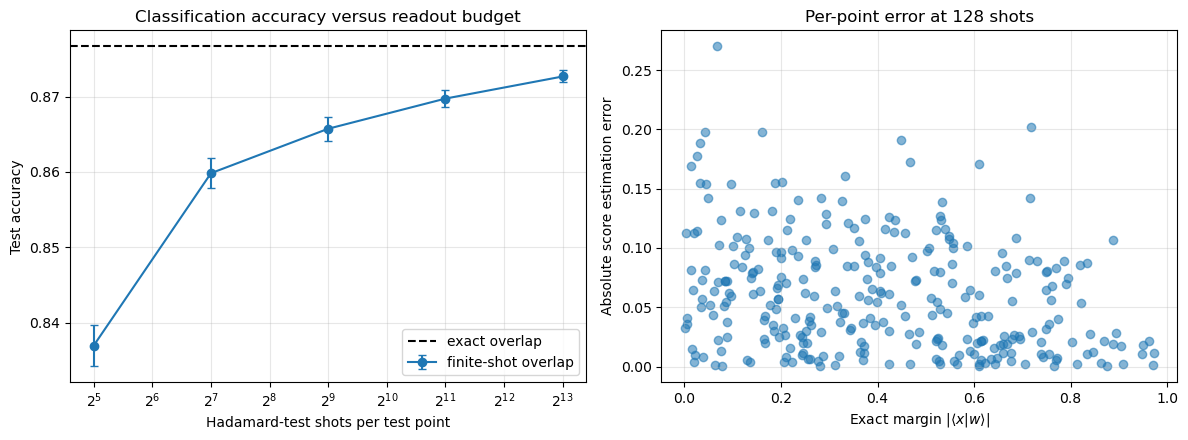

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(
    shot_sweep["S_shots_per_test_point"],
    shot_sweep["mean_accuracy"],
    yerr=shot_sweep["accuracy_ci95"],
    marker="o",
    capsize=3,
    label="finite-shot overlap",
)
axes[0].axhline(
    accuracy(test_y, exact_predictions),
    color="black",
    linestyle="--",
    label="exact overlap",
)
axes[0].set_xscale("log", base=2)
axes[0].set(
    xlabel="Hadamard-test shots per test point",
    ylabel="Test accuracy",
    title="Classification accuracy versus readout budget",
)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

final_scores = hadamard_test_estimate(
    exact_scores, shot_values[1], np.random.default_rng(SEED + 4)
)
axes[1].scatter(
    np.abs(exact_scores),
    np.abs(final_scores - exact_scores),
    alpha=0.55,
)
axes[1].set(
    xlabel=r"Exact margin $|\langle x|w\rangle|$",
    ylabel="Absolute score estimation error",
    title=f"Per-point error at {shot_values[1]} shots",
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 下一步如何替换理想态制备

当前链路是：

```text
classical streaming accumulator
    → ideal normalization |w>
    → simulated Hadamard-test shots
    → sign(score)
```

下一阶段要替换为：

```text
sample-dependent vector QOS updates
    → QSVT/LCU state extraction
    → |w>
    → Hadamard test
    → sign(score)
```

验收时必须同时报告：

- vector sketch 与理想 $|w\rangle$ 的 state fidelity；
- state-extraction 成功概率；
- Hadamard-test shots；
- classification margin；
- 经典控制缓冲区与逻辑 qubits；
- 不使用理想态制备占位的最终 accuracy。